In [1]:
import os, socket
import torch
import torch.nn as nn
from diffusers import StableDiffusionPipeline, DDIMScheduler
from safetensors.torch import load_file
from pytorch_lightning import seed_everything
from dataclasses import dataclass
from typing import Optional, Tuple
import gc
from torch import optim
import torchvision
from torchvision import transforms
import clip
from PIL import Image
from torch.utils.checkpoint import checkpoint
from torch.multiprocessing import Pool, set_start_method
from tqdm import tqdm
import logging
from datetime import datetime

/home/amarkr/venvs/dent/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [2]:
pipe= StableDiffusionPipeline.from_pretrained(
                'runwayml/stable-diffusion-v1-5',
                safety_checker=None,
                torch_dtype=torch.float16,
                use_safetensors=True,
                low_cpu_mem_usage=True,
            )
pipe = pipe.to('cuda:0')

/home/amarkr/venvs/dent/lib/python3.10/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/home/amarkr/venvs/dent/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


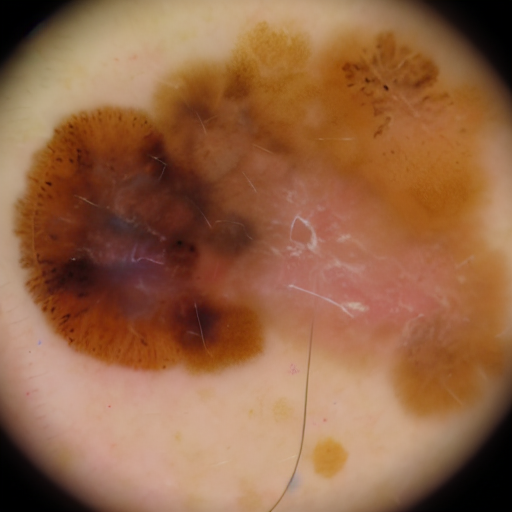

In [3]:
image_path = '/home/jupyter/dent_outputs/isic2019/melanoma//hairs_seed10_lambdaTstar5_style.png'
image = Image.open(image_path).convert('RGB')
image

In [4]:
transform = transforms.Compose([
                transforms.Resize((512, 512)),
                transforms.ToTensor(),
                transforms.Normalize(
                                mean=[0.5],
                                std=[0.5]
                            )
            ])
img = transform(image).unsqueeze(0).half().to("cuda:0")

In [5]:
img.min(), img.max()

(tensor(-1., device='cuda:0', dtype=torch.float16),
 tensor(0.6704, device='cuda:0', dtype=torch.float16))

In [6]:
latent = pipe.vae.encode(img)
latent

AutoencoderKLOutput(latent_dist=<diffusers.models.vae.DiagonalGaussianDistribution object at 0x7efc302ea380>)

In [7]:
latent.latent_dist.sample().flatten()

tensor([-10.0469, -10.0625, -11.8672,  ...,   5.7344,   8.6094,   8.6016],
       device='cuda:0', dtype=torch.float16, grad_fn=<ViewBackward0>)

In [8]:
output = pipe.vae.decode(latent.latent_dist.sample())

In [9]:
im = output[0]#.squeeze().permute(1,2,0).cpu()
im = (im/2 + 0.5).clamp(0,1)
#torch save the image
import torchvision.utils as vutils
vutils.save_image(im, 'output_image.png')


# Compute the cosine similarity

In [12]:
import os 
import glob
import numpy as np
